# 01 — Data Understanding
**Goal**: Load all 4 source files, understand their structure, validate joins, audit nulls, and document every anomaly found.  
**Output**: `data/processed/01_audit_report.md` + clean mental model of the dataset before any transformation.

## 0. Imports & Config

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
RAW   = Path('../data/raw')
PROC  = Path('../data/processed')
PROC.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete. RAW path exists:', RAW.exists())

import os

# Create all required output folders if they don't exist
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Folders ready.')

Setup complete. RAW path exists: True
Folders ready.


---
## 1. Load All Four Files

In [15]:
# ── Load ───────────────────────────────────────────────────────────────────
# Adjust filenames to match whatever is actually in data/raw/
loyalty  = pd.read_csv(RAW / 'Customer Loyalty History.csv')
activity = pd.read_csv(RAW / 'Customer Flight Activity.csv')
calendar = pd.read_csv(RAW / 'Calendar.csv')
# Data dictionary is reference only — load to inspect column definitions
try:
    data_dict = pd.read_csv(RAW / 'Data Dictionary.csv')
    print('Data dictionary loaded:', data_dict.shape)
except FileNotFoundError:
    print('Data dictionary not found as CSV — check if it is an Excel file')
    data_dict = None

print('\n--- Shapes ---')
print(f'loyalty  : {loyalty.shape}')
print(f'activity : {activity.shape}')
print(f'calendar : {calendar.shape}')

Data dictionary not found as CSV — check if it is an Excel file

--- Shapes ---
loyalty  : (16737, 16)
activity : (392936, 8)
calendar : (2557, 4)


---
## 2. Schema Inspection — Every Column, Every File

In [16]:
def schema_summary(df, name):
    """Print dtypes, null counts, and sample values for every column."""
    print(f'\n{'='*60}')
    print(f'  {name}  ({df.shape[0]:,} rows × {df.shape[1]} cols)')
    print(f'{'='*60}')
    summary = pd.DataFrame({
        'dtype'      : df.dtypes,
        'null_count' : df.isnull().sum(),
        'null_%'     : (df.isnull().mean() * 100).round(2),
        'n_unique'   : df.nunique(),
        'sample'     : df.apply(lambda c: c.dropna().iloc[0] if c.dropna().shape[0] > 0 else 'ALL NULL')
    })
    display(summary)

schema_summary(loyalty,  'Customer Loyalty History')
schema_summary(activity, 'Customer Flight Activity')
schema_summary(calendar, 'Calendar')


  Customer Loyalty History  (16,737 rows × 16 cols)


,dtype,null_count,null_%,n_unique,sample
Loyalty Number,int64,0,0.00,16737,480934
Country,object,0,0.00,1,Canada
Province,object,0,0.00,11,Ontario
City,object,0,0.00,29,Toronto
Postal Code,object,0,0.00,55,M2Z 4K1
Gender,object,0,0.00,2,Female
Education,object,0,0.00,5,Bachelor
Salary,float64,4238,25.32,5890,83236.0
Marital Status,object,0,0.00,3,Married
Loyalty Card,object,0,0.00,3,Star



  Customer Flight Activity  (392,936 rows × 8 cols)


,dtype,null_count,null_%,n_unique,sample
Loyalty Number,int64,0,0.0,16737,100590.0
Year,int64,0,0.0,2,2018.0
Month,int64,0,0.0,12,6.0
Total Flights,int64,0,0.0,17,12.0
Distance,int64,0,0.0,9456,15276.0
Points Accumulated,float64,0,0.0,10284,22914.0
Points Redeemed,int64,0,0.0,587,0.0
Dollar Cost Points Redeemed,int64,0,0.0,108,0.0



  Calendar  (2,557 rows × 4 cols)


,dtype,null_count,null_%,n_unique,sample
Date,object,0,0.0,2557,2012-01-01
Start of Year,object,0,0.0,7,2012-01-01
Start of Quarter,object,0,0.0,28,2012-01-01
Start of Month,object,0,0.0,84,2012-01-01


---
## 3. Join Key Validation
The two core tables must join on `Loyalty Number`.  
Activity is monthly time-series — confirm the grain is one row per member per month.

In [17]:
# ── Standardise column names to snake_case for convenience ─────────────────
loyalty.columns  = loyalty.columns.str.strip().str.lower().str.replace(' ', '_')
activity.columns = activity.columns.str.strip().str.lower().str.replace(' ', '_')
calendar.columns = calendar.columns.str.strip().str.lower().str.replace(' ', '_')

print('Loyalty cols :', list(loyalty.columns))
print('Activity cols:', list(activity.columns))
print('Calendar cols:', list(calendar.columns))

Loyalty cols : ['loyalty_number', 'country', 'province', 'city', 'postal_code', 'gender', 'education', 'salary', 'marital_status', 'loyalty_card', 'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month', 'cancellation_year', 'cancellation_month']
Activity cols: ['loyalty_number', 'year', 'month', 'total_flights', 'distance', 'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed']
Calendar cols: ['date', 'start_of_year', 'start_of_quarter', 'start_of_month']


In [18]:
# ── Key: loyalty_number (adjust name if different after rename) ─────────────
KEY = 'loyalty_number'

loyalty_ids  = set(loyalty[KEY])
activity_ids = set(activity[KEY])

in_both          = loyalty_ids & activity_ids
only_in_loyalty  = loyalty_ids - activity_ids
only_in_activity = activity_ids - loyalty_ids

print(f'Members in loyalty table      : {len(loyalty_ids):,}')
print(f'Members in activity table     : {len(activity_ids):,}')
print(f'Members in BOTH tables        : {len(in_both):,}')
print(f'Only in loyalty (no activity) : {len(only_in_loyalty):,}  ← potential inactive members')
print(f'Only in activity (no profile) : {len(only_in_activity):,}  ← data quality issue if > 0')

Members in loyalty table      : 16,737
Members in activity table     : 16,737
Members in BOTH tables        : 16,737
Only in loyalty (no activity) : 0  ← potential inactive members
Only in activity (no profile) : 0  ← data quality issue if > 0


In [19]:
# ── Verify grain: activity should be 1 row per member per year-month ────────
# Identify the year/month columns (adjust names as needed)
YEAR_COL  = 'year'
MONTH_COL = 'month'

grain_check = activity.groupby([KEY, YEAR_COL, MONTH_COL]).size()
duplicates  = grain_check[grain_check > 1]

print(f'\nActivity grain check (member × year × month):')
print(f'  Total rows       : {len(activity):,}')
print(f'  Duplicate grains : {len(duplicates):,}  ← should be 0')

if len(duplicates) > 0:
    print('\n⚠ DUPLICATES FOUND — sample:')
    display(duplicates.head(10).reset_index())


Activity grain check (member × year × month):
  Total rows       : 392,936
  Duplicate grains : 3,847  ← should be 0

⚠ DUPLICATES FOUND — sample:


,loyalty_number,year,month,0
0,101902,2017,1,2
1,101902,2017,2,2
2,101902,2017,3,2
3,101902,2017,4,2
4,101902,2017,5,2
5,101902,2017,6,2
6,101902,2017,7,2
7,101902,2017,8,2
8,101902,2017,9,2
9,101902,2017,10,2


---
## 4. Date Range Analysis
Confirm the dataset runs 2012–2018 as stated in the problem statement.

In [20]:
print('Activity year range :', activity[YEAR_COL].min(), '—', activity[YEAR_COL].max())
print('Activity month range:', activity[MONTH_COL].min(), '—', activity[MONTH_COL].max())

# ── Check for missing year-month combinations (calendar gaps) ───────────────
# Build expected full grid
years  = range(activity[YEAR_COL].min(), activity[YEAR_COL].max() + 1)
months = range(1, 13)
expected_periods = len(list(years)) * 12
actual_periods   = activity.groupby([YEAR_COL, MONTH_COL]).ngroups

print(f'\nExpected year-month periods : {expected_periods}')
print(f'Actual year-month periods   : {actual_periods}')
print(f'Missing periods             : {expected_periods - actual_periods}')

Activity year range : 2017 — 2018
Activity month range: 1 — 12

Expected year-month periods : 24
Actual year-month periods   : 24
Missing periods             : 0


In [21]:
# ── Enrollment date vs first activity: check for impossible records ──────────
# Members active BEFORE their enrollment date = data leakage candidate
# Adjust 'enrollment_year' / 'enrollment_month' column names as needed

if 'enrollment_year' in loyalty.columns:
    enroll_info = loyalty[[KEY, 'enrollment_year']].copy()
    first_activity = activity.groupby(KEY)[YEAR_COL].min().reset_index()
    first_activity.columns = [KEY, 'first_active_year']

    merged_enroll = enroll_info.merge(first_activity, on=KEY, how='inner')
    pre_enroll = merged_enroll[merged_enroll['first_active_year'] < merged_enroll['enrollment_year']]

    print(f'Members with activity BEFORE enrollment year: {len(pre_enroll):,}')
    if len(pre_enroll) > 0:
        print('\n⚠ These are data leakage risks — document and exclude from training:')
        display(pre_enroll.head())
else:
    print('Enrollment year column not found — check loyalty column names above')

Members with activity BEFORE enrollment year: 2,039

⚠ These are data leakage risks — document and exclude from training:


,loyalty_number,enrollment_year,first_active_year
12,611765,2018,2017
21,552965,2018,2017
34,806030,2018,2017
46,758635,2018,2017
47,823048,2018,2017


---
## 5. Loyalty Table — Demographic & CLV Distributions

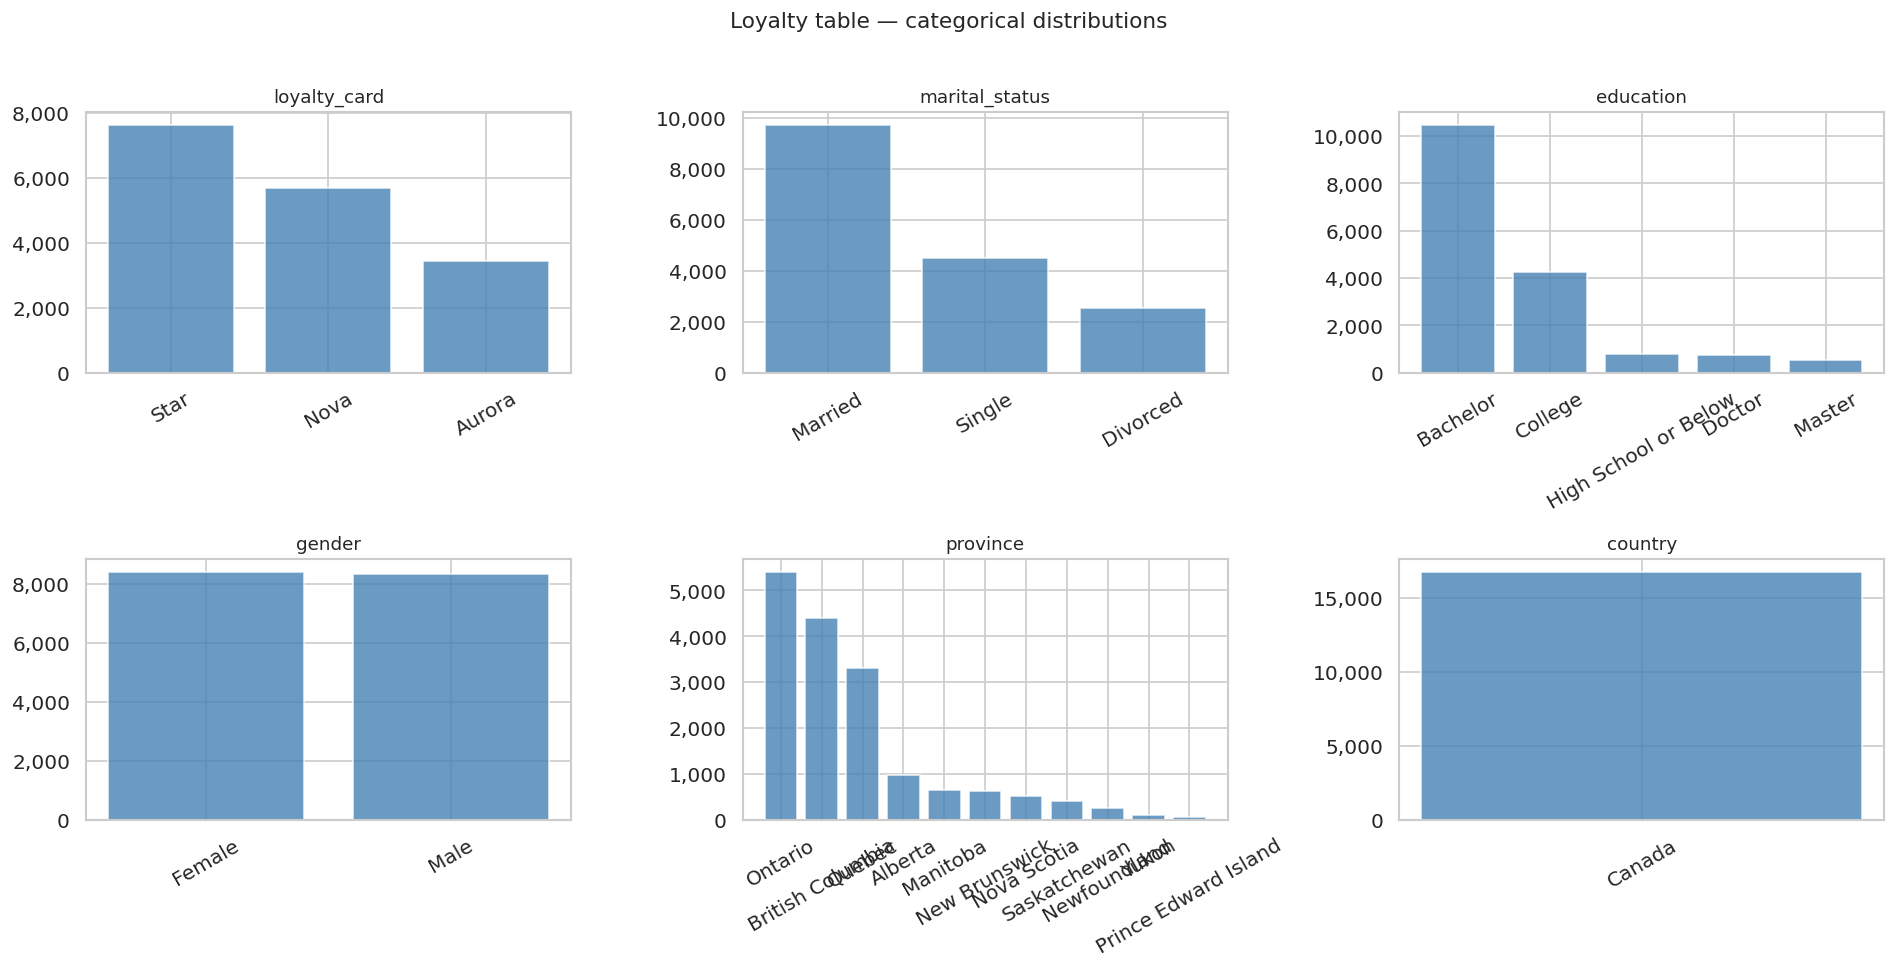

In [22]:
# ── Categorical columns: value counts ───────────────────────────────────────
CAT_COLS = ['loyalty_card', 'marital_status', 'education', 'gender',
            'province', 'country']  # adjust to actual column names

CAT_COLS = [c for c in CAT_COLS if c in loyalty.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS[:6]):
    vc = loyalty[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Loyalty table — categorical distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_categorical_distributions.png', bbox_inches='tight')
plt.show()

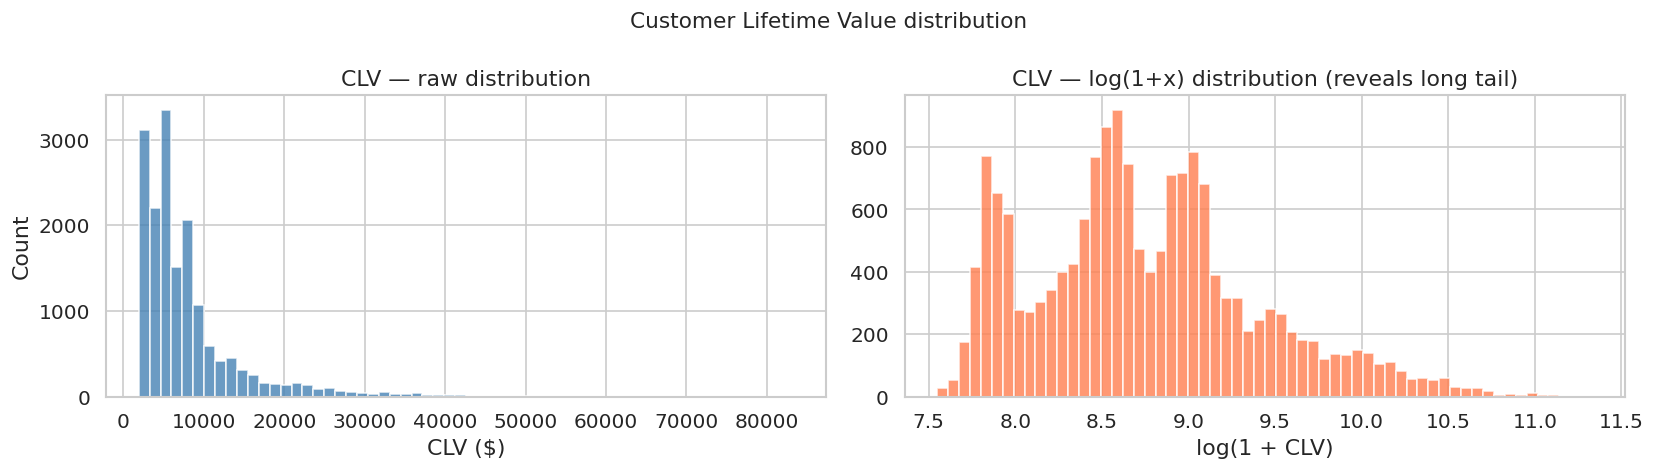


CLV descriptive stats:
count    16737.00
mean      7988.90
std       6860.98
min       1898.01
25%       3980.84
50%       5780.18
75%       8940.58
max      83325.38
Name: clv, dtype: float64

Zero or negative CLV members: 0  ← investigate
Null CLV members            : 0


In [23]:
# ── CLV distribution — the metric you are going to challenge ────────────────
# Adjust 'clv' to the actual column name (e.g. 'customer_lifetime_value')
CLV_COL = 'clv'
if CLV_COL not in loyalty.columns:
    # Try common alternatives
    for candidate in ['customer_lifetime_value', 'lifetime_value', 'ltv']:
        if candidate in loyalty.columns:
            CLV_COL = candidate
            print(f'CLV column found as: {CLV_COL}')
            break

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
axes[0].hist(loyalty[CLV_COL].dropna(), bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('CLV — raw distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].set_ylabel('Count')

# Log-scale to reveal the long tail
clv_pos = loyalty[CLV_COL][loyalty[CLV_COL] > 0].dropna()
axes[1].hist(np.log1p(clv_pos), bins=60, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_title('CLV — log(1+x) distribution (reveals long tail)')
axes[1].set_xlabel('log(1 + CLV)')

plt.suptitle('Customer Lifetime Value distribution', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/01_clv_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nCLV descriptive stats:')
print(loyalty[CLV_COL].describe().round(2))
print(f'\nZero or negative CLV members: {(loyalty[CLV_COL] <= 0).sum():,}  ← investigate')
print(f'Null CLV members            : {loyalty[CLV_COL].isnull().sum():,}')

---
## 6. Activity Table — Flight & Points Behaviour Over Time

In [24]:
# ── Build a year-month date column for time-series plots ────────────────────
activity['period'] = pd.to_datetime(
    activity[YEAR_COL].astype(str) + '-' + activity[MONTH_COL].astype(str).str.zfill(2)
)

# ── Identify numeric columns for aggregation ────────────────────────────────
# Typical names — adjust to match your actual columns
FLIGHTS_COL  = 'total_flights'
DISTANCE_COL = 'distance'
POINTS_ACC   = 'points_accumulated'
POINTS_RED   = 'points_redeemed'

available = {c: c in activity.columns for c in [FLIGHTS_COL, DISTANCE_COL, POINTS_ACC, POINTS_RED]}
print('Column availability:', available)
print('\nAll activity columns:', list(activity.columns))

Column availability: {'total_flights': True, 'distance': True, 'points_accumulated': True, 'points_redeemed': True}

All activity columns: ['loyalty_number', 'year', 'month', 'total_flights', 'distance', 'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed', 'period']


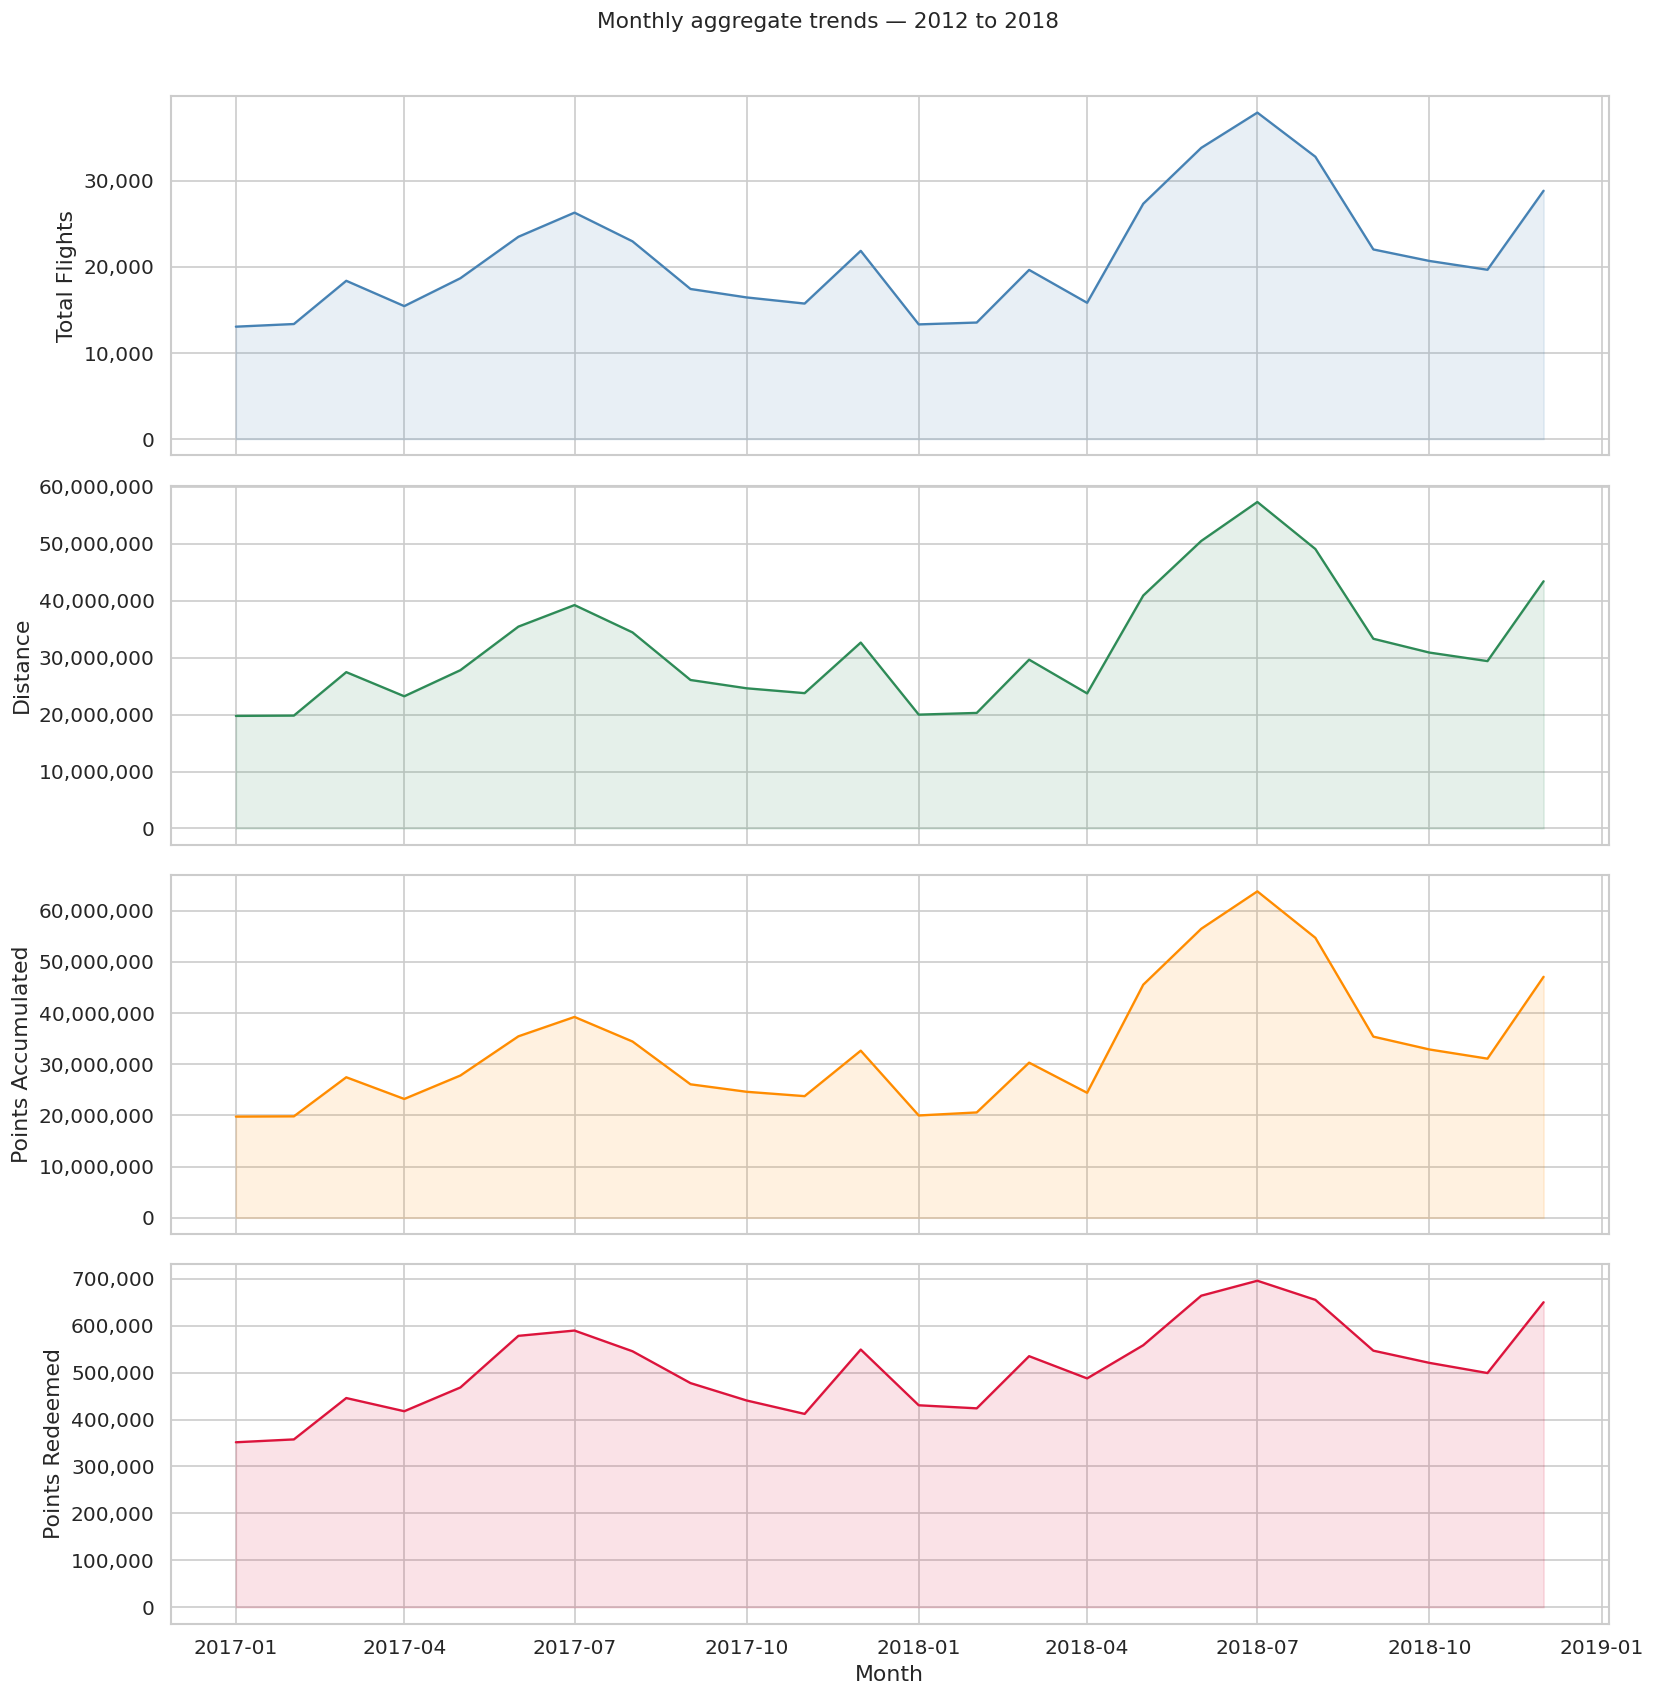

In [25]:
# ── Monthly aggregate trends ─────────────────────────────────────────────────
agg_cols = {c: 'sum' for c in [FLIGHTS_COL, DISTANCE_COL, POINTS_ACC, POINTS_RED]
            if c in activity.columns}

monthly = activity.groupby('period').agg(agg_cols).reset_index().sort_values('period')

fig, axes = plt.subplots(len(agg_cols), 1, figsize=(14, 3.5 * len(agg_cols)), sharex=True)
if len(agg_cols) == 1:
    axes = [axes]

colors = ['steelblue', 'seagreen', 'darkorange', 'crimson']
for ax, (col, _), color in zip(axes, agg_cols.items(), colors):
    ax.plot(monthly['period'], monthly[col], color=color, linewidth=1.4)
    ax.fill_between(monthly['period'], monthly[col], alpha=0.12, color=color)
    ax.set_ylabel(col.replace('_', ' ').title())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[-1].set_xlabel('Month')
plt.suptitle('Monthly aggregate trends — 2012 to 2018', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_monthly_trends.png', bbox_inches='tight')
plt.show()

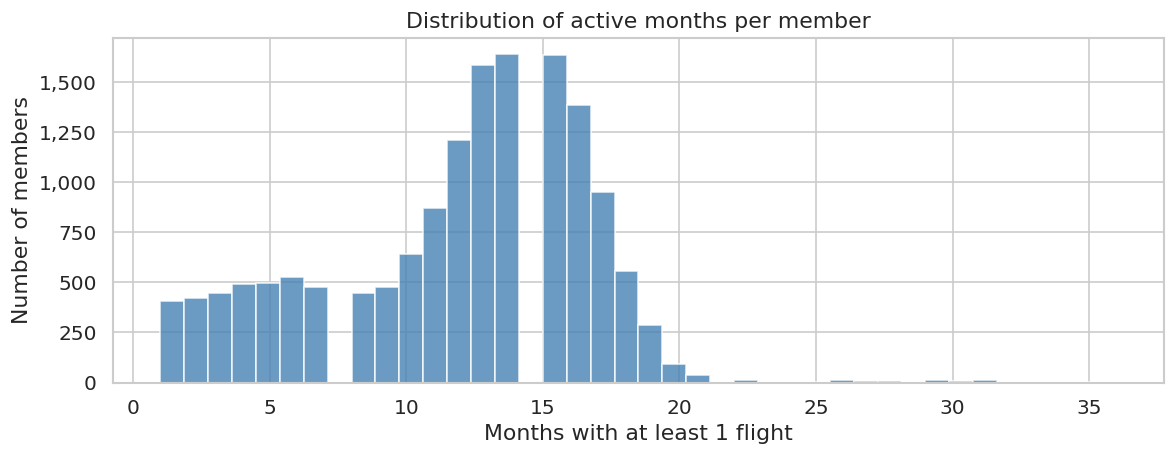

Members with 0 flights ever  : 0
Median active months         : 13.0
Members active < 3 months    : 828


In [26]:
# ── Per-member activity: how many months is each member active? ──────────────
member_active_months = activity[activity[FLIGHTS_COL] > 0].groupby(KEY).size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(member_active_months, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Months with at least 1 flight')
ax.set_ylabel('Number of members')
ax.set_title('Distribution of active months per member')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../reports/figures/01_active_months_distribution.png', bbox_inches='tight')
plt.show()

print(f'Members with 0 flights ever  : {(member_active_months == 0).sum():,}')
print(f'Median active months         : {member_active_months.median()}')
print(f'Members active < 3 months    : {(member_active_months < 3).sum():,}')

---
## 7. Cancellation & Churn Signal Audit
The PS says formal cancellations exist but are not the only churn signal.  
This section sets up that argument.

In [27]:
# ── Check for cancellation columns in loyalty table ──────────────────────────
cancel_cols = [c for c in loyalty.columns if 'cancel' in c.lower() or 'churn' in c.lower()]
print('Cancellation-related columns found:', cancel_cols)

if cancel_cols:
    for col in cancel_cols:
        print(f'\n{col} value counts:')
        print(loyalty[col].value_counts(dropna=False))

Cancellation-related columns found: ['cancellation_year', 'cancellation_month']

cancellation_year value counts:
cancellation_year
NaN       14670
2018.0      645
2017.0      506
2016.0      427
2015.0      265
2014.0      181
2013.0       43
Name: count, dtype: int64

cancellation_month value counts:
cancellation_month
NaN     14670
12.0      213
11.0      212
8.0       208
7.0       186
10.0      180
9.0       176
6.0       165
1.0       155
3.0       149
5.0       148
2.0       139
4.0       136
Name: count, dtype: int64


In [28]:
# ── Behavioural churn signal: members who stopped flying without cancelling ──
# This is your key argument for defining a richer churn definition in notebook 02

# Last active month per member
last_active = activity[activity[FLIGHTS_COL] > 0].groupby(KEY)['period'].max().reset_index()
last_active.columns = [KEY, 'last_flight_month']

DATASET_END = activity['period'].max()
last_active['months_since_last_flight'] = (
    (DATASET_END.year  - last_active['last_flight_month'].dt.year)  * 12 +
    (DATASET_END.month - last_active['last_flight_month'].dt.month)
)

print(f'Dataset end date: {DATASET_END.strftime("%Y-%m")}')
print('\nMonths since last flight — distribution:')
print(last_active['months_since_last_flight'].describe().round(1))

# Members inactive for 6+ months at dataset end (a preview of churn)
behavioural_churners = (last_active['months_since_last_flight'] >= 6).sum()
print(f'\nMembers inactive for ≥6 months at dataset end: {behavioural_churners:,}')

if cancel_cols:
    # How many of these formally cancelled vs just went quiet?
    merged_cancel = last_active.merge(loyalty[[KEY] + cancel_cols], on=KEY, how='left')
    for col in cancel_cols:
        print(f'\nOf those {behavioural_churners:,} inactive members, formal cancellation ({col}):')
        subset = merged_cancel[merged_cancel['months_since_last_flight'] >= 6]
        print(subset[col].value_counts(dropna=False))

Dataset end date: 2018-12

Months since last flight — distribution:
count    15167.0
mean         1.4
std          3.5
min          0.0
25%          0.0
50%          0.0
75%          1.0
max         23.0
Name: months_since_last_flight, dtype: float64

Members inactive for ≥6 months at dataset end: 899

Of those 899 inactive members, formal cancellation (cancellation_year):
cancellation_year
2017.0    476
2018.0    315
NaN       108
Name: count, dtype: int64

Of those 899 inactive members, formal cancellation (cancellation_month):
cancellation_month
NaN     108
5.0      90
3.0      87
6.0      87
1.0      79
4.0      76
7.0      72
2.0      70
8.0      52
11.0     50
12.0     49
9.0      41
10.0     38
Name: count, dtype: int64


---
## 8. Anomaly Summary & Audit Log
Document every issue found. This section becomes your cleaning decision log for the report.

In [29]:
# ── Numeric outlier check — activity table ───────────────────────────────────
num_cols = [c for c in [FLIGHTS_COL, DISTANCE_COL, POINTS_ACC, POINTS_RED]
            if c in activity.columns]

print('Extreme value check (>99th percentile):')
for col in num_cols:
    p99 = activity[col].quantile(0.99)
    extreme = (activity[col] > p99).sum()
    max_val = activity[col].max()
    print(f'  {col:<30} 99th pct={p99:>10.0f}  max={max_val:>12.0f}  n_extreme={extreme:,}')

Extreme value check (>99th percentile):
  total_flights                  99th pct=         6  max=          28  n_extreme=3,062
  distance                       99th pct=     12185  max=       67284  n_extreme=3,929
  points_accumulated             99th pct=     12750  max=      100926  n_extreme=3,929
  points_redeemed                99th pct=       639  max=         876  n_extreme=3,928


In [30]:
# ── Negative values check ────────────────────────────────────────────────────
print('Negative value check:')
for col in num_cols:
    neg = (activity[col] < 0).sum()
    if neg > 0:
        print(f'  ⚠ {col}: {neg:,} negative values')
    else:
        print(f'  ✓ {col}: no negatives')

Negative value check:
  ✓ total_flights: no negatives
  ✓ distance: no negatives
  ✓ points_accumulated: no negatives
  ✓ points_redeemed: no negatives


In [31]:
# ── Write audit report to file ───────────────────────────────────────────────
audit_lines = [
    '# Data Audit Report — 01_data_understanding\n',
    f'## File shapes',
    f'- loyalty  : {loyalty.shape}',
    f'- activity : {activity.shape}',
    f'- calendar : {calendar.shape}',
    '',
    '## Join key check',
    f'- Members in both tables        : {len(in_both):,}',
    f'- Only in loyalty (no activity) : {len(only_in_loyalty):,}',
    f'- Only in activity (no profile) : {len(only_in_activity):,}',
    '',
    '## Date range',
    f'- Activity covers: {activity[YEAR_COL].min()} to {activity[YEAR_COL].max()}',
    f'- Dataset end month: {DATASET_END.strftime("%Y-%m")}',
    '',
    '## Behavioural churn preview',
    f'- Members inactive ≥6 months at dataset end: {behavioural_churners:,}',
    f'- (Formal cancellation count will differ — see notebook 02)',
    '',
    '## Issues to address in 02_data_cleaning',
    '- [ ] Zero/negative CLV members',
    '- [ ] Members active before enrollment date',
    '- [ ] Duplicate grains in activity table (if any)',
    '- [ ] Extreme outliers in flights/distance/points',
    '- [ ] Confirm calendar table join logic',
]

audit_path = PROC / '01_audit_report.md'
audit_path.write_text('\n'.join(audit_lines))
print(f'Audit report saved to: {audit_path}')

Audit report saved to: ../data/processed/01_audit_report.md


---
## 9. Merged Preview — Confirm Full Join Works

In [32]:
# ── Merge loyalty + activity + calendar ─────────────────────────────────────
# Left join: keep all activity rows, bring in member profile
merged = activity.merge(loyalty, on=KEY, how='left')

# Join calendar on year + month to bring in quarter/season labels
# Calendar likely has columns: year, month, quarter, season — adjust as needed
if 'quarter' not in merged.columns and 'quarter' in calendar.columns:
    cal_key_cols = [c for c in [YEAR_COL, MONTH_COL] if c in calendar.columns]
    merged = merged.merge(calendar[cal_key_cols + ['quarter', 'season']],
                          on=cal_key_cols, how='left')

print(f'Merged table shape: {merged.shape}')
print(f'Columns added from calendar: quarter/season present: {"quarter" in merged.columns}')
display(merged.head(3))

Merged table shape: (392936, 24)
Columns added from calendar: quarter/season present: False


,loyalty_number,year,month,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,period,country,...,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,100590,2018,6,12,15276,22914.0,0,0,2018-06-01,Canada,...,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN
1,100590,2018,7,12,9168,13752.0,0,0,2018-07-01,Canada,...,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN
2,100590,2018,5,4,6504,9756.0,0,0,2018-05-01,Canada,...,Bachelor,69841.0,Married,Star,34090.04,2018 Promotion,2018,3,NaN,NaN


In [33]:
# ── Save merged base table for use in notebook 02 ───────────────────────────
merged.to_csv(PROC / '01_merged_base.csv', index=False)
print(f'Saved: {PROC / "01_merged_base.csv"}  ({merged.shape[0]:,} rows)')
print('\nNext step → 02_data_cleaning.ipynb')

Saved: ../data/processed/01_merged_base.csv  (392,936 rows)

Next step → 02_data_cleaning.ipynb
